# Latest GW Player Picker Dashboard

Use this notebook to shortlist players by position, inspect predicted points, and generate plots you can share with your league group.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(str(Path('../..').resolve()))
from latest_gw_tools import load_latest_outputs, load_gw_outputs
from squad_selection import get_best_11, get_best_11_noadj, get_owner_dict

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

In [2]:
# Leave TARGET_GW as None to auto-load latest available GW output.
TARGET_GW = 4
TOP_N = 20
BACKTEST_YEAR = 26
EXPORT_FIGURES = False
FIG_DIR = Path('..') / 'figures'

if EXPORT_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
if TARGET_GW is None:
    latest_gw, pred_simple, pred_full, fixture_difficulty = load_latest_outputs(predictions_dir='../predictions', fixture_dir='../fixture_difficulty')
else:
    latest_gw = TARGET_GW
    pred_simple, pred_full, fixture_difficulty = load_gw_outputs(TARGET_GW, predictions_dir='../predictions', fixture_dir='../fixture_difficulty')

print(f'Loaded GW: {latest_gw}')
print(f'Players in simple output: {len(pred_simple):,}')
print(f'Players in full output: {len(pred_full):,}')

Loaded GW: 4
Players in simple output: 655
Players in full output: 655


In [4]:
df = pred_simple.copy()
if 'predicted_points_adj' not in df.columns:
    df['predicted_points_adj'] = df['predicted_points']

owner_dict = get_owner_dict()
owner_name_map = {str(int(k)): v for k, v in owner_dict.items()}
df['owner_name'] = df['owner'].fillna(-1).astype(int).astype(str).map(owner_name_map).fillna('Free Agent')

# Combine duplicate player rows (e.g., double gameweeks) into one row per player/team/position/owner.
group_cols = ['full_name', 'team', 'position', 'owner_name']
for col in ['predicted_points', 'predicted_points_adj', 'fixture_diff_index']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

agg_dict = {
    'predicted_points': 'sum',
    'predicted_points_adj': 'sum',
}
if 'fixture_diff_index' in df.columns:
    agg_dict['fixture_diff_index'] = 'mean'

df = (
    df.groupby(group_cols, as_index=False)
    .agg(agg_dict)
)

# --- Multi-GW horizon means: mean predicted points (adjusted) over the next 3/6
# GWs starting at latest_gw. A blank GW for a player is excluded from their
# average (not counted as zero) -- matches the horizon methodology in WORKFLOW.md.
predictions_dir = Path('..') / 'predictions'

def load_horizon_mean_adj(start_gw, n_gws, predictions_dir=predictions_dir):
    frames = []
    for gw in range(start_gw, start_gw + n_gws):
        path = predictions_dir / f'predicted_gw{gw}_simple.csv'
        if not path.exists():
            break
        gw_df = pd.read_csv(path)
        if 'predicted_points_adj' not in gw_df.columns:
            gw_df['predicted_points_adj'] = gw_df['predicted_points']
        # Combine double-gameweek duplicates within this GW before averaging across GWs.
        gw_df = (
            gw_df.groupby(['full_name', 'team', 'position'], as_index=False)
            [['predicted_points_adj']].sum()
        )
        frames.append(gw_df)
    if not frames:
        return pd.DataFrame(columns=['full_name', 'team', 'position', 'predicted_points_adj'])
    return (
        pd.concat(frames, ignore_index=True)
        .groupby(['full_name', 'team', 'position'], as_index=False)
        .mean(numeric_only=True)
    )

horizon_3gw = load_horizon_mean_adj(latest_gw, 3).rename(columns={'predicted_points_adj': 'predicted_points_adj_3gw'})
horizon_6gw = load_horizon_mean_adj(latest_gw, 6).rename(columns={'predicted_points_adj': 'predicted_points_adj_6gw'})

df = df.merge(horizon_3gw, on=['full_name', 'team', 'position'], how='left')
df = df.merge(horizon_6gw, on=['full_name', 'team', 'position'], how='left')

rank_col = 'predicted_points'
df_sorted = df.sort_values(rank_col, ascending=False).reset_index(drop=True)
df_sorted.head(10)

,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index,predicted_points_adj_3gw,predicted_points_adj_6gw
0,bruno_borges_fernandes,Man Utd,MID,Lucas,5.952156,5.469668,0.918939,7.322797,7.035839
1,erling_haaland,Man City,FWD,Rory D,5.921801,9.899650,1.671729,9.506332,9.799536
2,bukayo_saka,Arsenal,MID,Arthur,5.332282,5.867893,1.100447,5.470413,6.251598
3,cole_palmer,Chelsea,MID,Richard,4.872068,3.955313,0.811835,4.694859,5.379146
4,joao_pedro_junqueira_de_jesus,Chelsea,FWD,Tobias,4.770818,5.136184,1.076584,6.121004,7.249860
5,cody_gakpo,Liverpool,MID,Rory D,4.730270,6.981515,1.475923,5.488713,4.647267
6,martin_odegaard,Arsenal,MID,Doug,4.647928,5.114798,1.100447,4.768331,5.449258
7,bryan_mbeumo,Man Utd,MID,Rory B,4.638302,4.262317,0.918939,5.706393,5.482778
8,bart_verbruggen,Brighton,GK,Tobias,4.604440,9.208879,2.000000,5.729969,4.604440
9,alexander_isak,Liverpool,FWD,Marcus,4.602130,9.204259,2.000000,7.237140,7.604582


In [5]:
## Position Shortlists

In [6]:
show_cols = ['full_name', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj',
             'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
position_lists = {}

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_df = (
        df_sorted
        .query('position == @pos')
        .loc[:, show_cols]
        .head(50)
        .reset_index(drop=True)
    )
    position_lists[pos] = pos_df
    print(f'\nTop {TOP_N} {pos}')
    display(pos_df)


Top 20 GK


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bart_verbruggen,Brighton,Tobias,4.604440,9.208879,5.729969,4.604440,2.000000
1,david_raya_martin,Arsenal,Doug,3.516092,5.469476,5.209025,5.209025,1.555556
2,alisson_becker,Liverpool,Richard,3.262027,4.832633,3.705019,3.382843,1.481481
3,konstantinos_tzolakis,Hull City,Free Agent,3.246535,6.252586,5.915908,6.204489,1.925926
4,gianluigi_donnarumma,Man City,Lucas,3.245505,6.250602,3.846524,4.367408,1.925926
5,jordan_pickford,Everton,Marcus,3.221389,6.442779,6.220065,4.422451,2.000000
6,james_trafford,Leeds,Arthur,3.124277,2.777135,4.165702,4.859986,0.888889
7,matz_sels,Nott'm Forest,Arthur,3.103372,6.206744,5.241251,4.275757,2.000000
8,caoimhin_kelleher,Brentford,Dave,3.063884,3.994397,4.206221,4.478566,1.303704
9,lukas_hornicek,Newcastle,Doug,3.042352,3.155032,5.033027,4.657428,1.037037



Top 20 DEF


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,gabriel_dos_santos_magalhaes,Arsenal,Doug,4.449611,6.391161,6.878029,6.781669,1.436341
1,james_tarkowski,Everton,Marcus,3.738118,7.476236,6.477344,4.555708,2.000000
2,marc_guehi,Man City,Dave,3.700749,7.401497,4.973925,5.087707,2.000000
3,luka_vuskovic,Brighton,Arthur,3.582313,7.164626,4.459350,3.862748,2.000000
4,josko_gvardiol,Man City,Will,3.561568,7.123136,4.786862,4.896365,2.000000
5,benjamin_white,Arsenal,Will,3.500126,5.027376,5.410353,5.334555,1.436341
6,jarrad_branthwaite,Everton,Tobias,3.475572,6.951143,6.022408,4.235739,2.000000
7,riccardo_calafiori,Arsenal,Richard,3.462254,4.972980,5.351813,5.276835,1.436341
8,tyrick_mitchell,Crystal Palace,Richard,3.365669,2.569750,3.331337,3.304456,0.763518
9,lewis_hall,Newcastle,Marcus,3.364312,4.336569,5.091389,4.774375,1.288991



Top 20 MID


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bruno_borges_fernandes,Man Utd,Lucas,5.952156,5.469668,7.322797,7.035839,0.918939
1,bukayo_saka,Arsenal,Arthur,5.332282,5.867893,5.470413,6.251598,1.100447
2,cole_palmer,Chelsea,Richard,4.872068,3.955313,4.694859,5.379146,0.811835
3,cody_gakpo,Liverpool,Rory D,4.730270,6.981515,5.488713,4.647267,1.475923
4,martin_odegaard,Arsenal,Doug,4.647928,5.114798,4.768331,5.449258,1.100447
5,bryan_mbeumo,Man Utd,Rory B,4.638302,4.262317,5.706393,5.482778,0.918939
6,marcus_tavernier,Bournemouth,Richard,4.597859,3.188099,5.138554,4.546886,0.693388
7,rayan_cherki,Man City,Marcus,4.551306,4.208473,5.055933,5.734612,0.924674
8,antoine_semenyo,Man City,Dave,4.479326,4.141915,4.975973,5.643918,0.924674
9,morgan_rogers,Chelsea,Dave,4.336579,3.520585,4.178848,4.787925,0.811835



Top 20 FWD


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,erling_haaland,Man City,Rory D,5.921801,9.899650,9.506332,9.799536,1.671729
1,joao_pedro_junqueira_de_jesus,Chelsea,Tobias,4.770818,5.136184,6.121004,7.249860,1.076584
2,alexander_isak,Liverpool,Marcus,4.602130,9.204259,7.237140,7.604582,2.000000
3,kai_havertz,Arsenal,Doug,4.274317,5.824814,5.106336,5.388671,1.362747
4,yoane_wissa,Newcastle,Will,3.943118,2.817827,4.005361,5.158803,0.714619
5,oli_mcburnie,Hull City,Tobias,3.705679,3.430559,3.406084,3.665714,0.925757
6,francisco_evanilson_de_lima_barbosa,Bournemouth,Richard,3.607089,4.743644,4.411223,3.820536,1.315089
7,gonzalo_garcia,Fulham,Marcus,3.585976,2.063419,3.819082,3.123666,0.575414
8,dominic_calvert_lewin,Leeds,Arthur,3.543282,1.825093,3.247455,3.043670,0.515085
9,igor_thiago_nascimento_rodrigues,Brentford,Rory B,3.488473,1.744237,2.080314,1.912275,0.500000


In [7]:
show_cols = ['full_name', 'team', 'position', 'owner_name', 'predicted_points', 'predicted_points_adj',
             'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
positions = ['GK', 'DEF', 'MID', 'FWD']

for pos in positions:
    doug_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Doug"')
        .loc[:, show_cols]
    )

    free_agent_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Free Agent"')
        .loc[:, show_cols]
        .head(20)
    )

    combined_pos = pd.concat([doug_pos, free_agent_pos], ignore_index=True)

    print(f'\n{pos}: Doug + Top Free Agents')
    display(combined_pos)



GK: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,david_raya_martin,Arsenal,GK,Doug,3.516092,5.469476,5.209025,5.209025,1.555556
1,lukas_hornicek,Newcastle,GK,Doug,3.042352,3.155032,5.033027,4.657428,1.037037
2,konstantinos_tzolakis,Hull City,GK,Free Agent,3.246535,6.252586,5.915908,6.204489,1.925926
3,kjell_scherpen,Ipswich Town,GK,Free Agent,2.846931,2.024484,2.108838,2.472612,0.711111
4,robert_lynch_sanchez,Chelsea,GK,Free Agent,0.920096,1.240426,0.890562,1.070038,1.348148
5,marco_bizot,Aston Villa,GK,Free Agent,0.759424,1.518848,1.353837,1.140073,2.000000
6,nick_pope,Newcastle,GK,Free Agent,0.525340,0.544797,0.869081,0.804224,1.037037
7,illan_meslier,Arsenal,GK,Free Agent,0.525234,0.817031,0.778125,0.778125,1.555556
8,kepa_arrizabalaga_revuelta,Arsenal,GK,Free Agent,0.525234,0.817031,0.778125,0.778125,1.555556
9,geronimo_rulli,Man City,GK,Free Agent,0.525182,1.011461,0.622438,0.706726,1.925926



DEF: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,gabriel_dos_santos_magalhaes,Arsenal,DEF,Doug,4.449611,6.391161,6.878029,6.781669,1.436341
1,nikola_milenkovic,Nott'm Forest,DEF,Doug,3.000911,6.001822,5.083721,3.793045,2.000000
2,abdukodir_khusanov,Man City,DEF,Doug,2.799158,5.598316,3.762159,3.848220,2.000000
3,nathan_collins,Brentford,DEF,Doug,2.211269,3.889519,3.283781,3.325926,1.758953
4,nico_o'reilly,Man City,DEF,Doug,1.904158,3.808315,2.559249,2.617794,2.000000
5,semi_ajayi,Hull City,DEF,Free Agent,3.051657,3.049324,3.125246,4.391643,0.999236
6,timothy_castagne,Fulham,DEF,Free Agent,3.032808,1.516404,2.162939,2.758295,0.500000
7,jayden_bogle,Leeds,DEF,Free Agent,3.018817,1.509408,2.757533,3.894878,0.500000
8,jan_paul_van_hecke,Spurs,DEF,Free Agent,2.920155,2.267124,4.357854,3.866488,0.776371
9,ryan_giles,Hull City,DEF,Free Agent,2.909839,2.907615,2.980009,4.187553,0.999236



MID: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,martin_odegaard,Arsenal,MID,Doug,4.647928,5.114798,4.768331,5.449258,1.100447
1,keane_lewis_potter,Brentford,MID,Doug,3.945828,4.412483,5.415207,4.941513,1.118265
2,diego_gomez_amarilla,Brighton,MID,Doug,3.680793,5.476118,4.113262,4.782366,1.487755
3,marcus_rashford,Man Utd,MID,Doug,3.020752,2.775887,3.716359,3.570727,0.918939
4,emiliano_buendia_stati,Aston Villa,MID,Doug,2.904766,1.638839,1.572095,1.621966,0.564190
5,josh_king,Fulham,MID,Free Agent,4.093851,3.810642,3.706512,3.524494,0.930821
6,oscar_bobb,Fulham,MID,Free Agent,3.613735,3.363741,3.271822,3.111151,0.930821
7,vitaly_janelt,Brentford,MID,Free Agent,3.605801,4.032243,4.948558,4.515684,1.118265
8,harvey_barnes,Newcastle,MID,Free Agent,3.561678,2.657533,3.153392,3.946436,0.746146
9,tyrique_george,Everton,MID,Free Agent,3.451173,3.486627,3.293859,3.215437,1.010273



FWD: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,kai_havertz,Arsenal,FWD,Doug,4.274317,5.824814,5.106336,5.388671,1.362747
1,omar_marmoush,Spurs,FWD,Doug,3.050061,4.386122,2.582167,2.761287,1.438044
2,georginio_rutter,Brighton,FWD,Doug,1.132489,1.210702,0.975867,1.063560,1.069063
3,taiwo_awoniyi,Coventry City,FWD,Free Agent,2.712896,2.017494,1.614111,1.941787,0.743668
4,matias_fernandez_pardo,Newcastle,FWD,Free Agent,1.541836,1.101826,1.566175,2.017193,0.714619
5,brandon_thomas_asante,Coventry City,FWD,Free Agent,1.474330,1.096412,0.877192,1.055269,0.743668
6,zian_flemming,Ipswich Town,FWD,Free Agent,1.366773,2.733547,2.733547,2.118870,2.000000
7,chuba_akpom,Ipswich Town,FWD,Free Agent,1.167024,2.334048,2.334048,1.809204,2.000000
8,promise_david,Brighton,FWD,Free Agent,1.132547,1.210765,0.975918,1.063615,1.069063
9,chris_wood,Nott'm Forest,FWD,Free Agent,1.083578,0.541789,0.782270,0.834801,0.500000


In [8]:
# A compact shortlist view you can screenshot/share.
shortlist = pd.concat(
    [
        position_lists[pos].assign(position=pos)
        for pos in ['GK', 'DEF', 'MID', 'FWD']
    ],
    ignore_index=True,
)

shortlist = shortlist[[
    'position', 'full_name', 'team', 'owner_name',
    'predicted_points', 'predicted_points_adj',
    'predicted_points_adj_3gw', 'predicted_points_adj_6gw',
    'fixture_diff_index'
 ]]
shortlist.head(40)

,position,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,GK,bart_verbruggen,Brighton,Tobias,4.604440,9.208879,5.729969,4.604440,2.000000
1,GK,david_raya_martin,Arsenal,Doug,3.516092,5.469476,5.209025,5.209025,1.555556
2,GK,alisson_becker,Liverpool,Richard,3.262027,4.832633,3.705019,3.382843,1.481481
3,GK,konstantinos_tzolakis,Hull City,Free Agent,3.246535,6.252586,5.915908,6.204489,1.925926
4,GK,gianluigi_donnarumma,Man City,Lucas,3.245505,6.250602,3.846524,4.367408,1.925926
5,GK,jordan_pickford,Everton,Marcus,3.221389,6.442779,6.220065,4.422451,2.000000
6,GK,james_trafford,Leeds,Arthur,3.124277,2.777135,4.165702,4.859986,0.888889
7,GK,matz_sels,Nott'm Forest,Arthur,3.103372,6.206744,5.241251,4.275757,2.000000
8,GK,caoimhin_kelleher,Brentford,Dave,3.063884,3.994397,4.206221,4.478566,1.303704
9,GK,lukas_hornicek,Newcastle,Doug,3.042352,3.155032,5.033027,4.657428,1.037037


In [9]:
## Team Selection Helpers

In [10]:
formation_adj, best_11_adj = get_best_11(df_sorted)
formation_raw, best_11_raw = get_best_11_noadj(df_sorted)

print(f'Best XI (adj) formation: {formation_adj}')
display(best_11_adj[['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj']])

print(f'Best XI (raw) formation: {formation_raw}')
display(best_11_raw[['full_name', 'position', 'team', 'owner_name', 'predicted_points']])

Best XI (adj) formation: {'GK': 1, 'DEF': 5, 'MID': 3, 'FWD': 2}

,full_name,position,team,owner_name,predicted_points,predicted_points_adj
9,erling_haaland,FWD,Man City,Rory D,5.921801,9.899650
0,bart_verbruggen,GK,Brighton,Tobias,4.604440,9.208879
10,alexander_isak,FWD,Liverpool,Marcus,4.602130,9.204259
1,james_tarkowski,DEF,Everton,Marcus,3.738118,7.476236
2,marc_guehi,DEF,Man City,Dave,3.700749,7.401497
3,luka_vuskovic,DEF,Brighton,Arthur,3.582313,7.164626
4,josko_gvardiol,DEF,Man City,Will,3.561568,7.123136
6,cody_gakpo,MID,Liverpool,Rory D,4.730270,6.981515
5,jarrad_branthwaite,DEF,Everton,Tobias,3.475572,6.951143
7,dominik_szoboszlai,MID,Liverpool,Rory D,4.022934,5.937542


Best XI (raw) formation: {'GK': 1, 'DEF': 3, 'MID': 5, 'FWD': 2}


,full_name,position,team,owner_name,predicted_points
4,bruno_borges_fernandes,MID,Man Utd,Lucas,5.952156
9,erling_haaland,FWD,Man City,Rory D,5.921801
5,bukayo_saka,MID,Arsenal,Arthur,5.332282
6,cole_palmer,MID,Chelsea,Richard,4.872068
10,joao_pedro_junqueira_de_jesus,FWD,Chelsea,Tobias,4.770818
7,cody_gakpo,MID,Liverpool,Rory D,4.730270
8,martin_odegaard,MID,Arsenal,Doug,4.647928
0,bart_verbruggen,GK,Brighton,Tobias,4.604440
1,gabriel_dos_santos_magalhaes,DEF,Arsenal,Doug,4.449611
2,james_tarkowski,DEF,Everton,Marcus,3.738118


In [11]:
doug_pool = df_sorted.query('owner_name == "Doug"').copy()
doug_formation, doug_best_11 = get_best_11(doug_pool)

print(f"Doug Best XI formation: {doug_formation['DEF']}-{doug_formation['MID']}-{doug_formation['FWD']}")
display(
    doug_best_11[
        ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
    ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
)

bench_key_cols = ['full_name', 'team', 'position']
bench_keys = set(
    tuple(row) for row in doug_best_11[bench_key_cols].drop_duplicates().itertuples(index=False, name=None)
)
bench_players = (
    doug_pool[
        ~doug_pool[bench_key_cols].apply(tuple, axis=1).isin(bench_keys)
    ][['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']]
    .sort_values('predicted_points_adj', ascending=False)
    .reset_index(drop=True)
)

print('Doug Bench Players:')
display(bench_players)

Doug Best XI formation: 5-3-2


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,gabriel_dos_santos_magalhaes,DEF,Arsenal,4.449611,6.391161,1.436341
1,nikola_milenkovic,DEF,Nott'm Forest,3.000911,6.001822,2.000000
2,abdukodir_khusanov,DEF,Man City,2.799158,5.598316,2.000000
3,nathan_collins,DEF,Brentford,2.211269,3.889519,1.758953
4,nico_o'reilly,DEF,Man City,1.904158,3.808315,2.000000
5,kai_havertz,FWD,Arsenal,4.274317,5.824814,1.362747
6,omar_marmoush,FWD,Spurs,3.050061,4.386122,1.438044
7,david_raya_martin,GK,Arsenal,3.516092,5.469476,1.555556
8,diego_gomez_amarilla,MID,Brighton,3.680793,5.476118,1.487755
9,martin_odegaard,MID,Arsenal,4.647928,5.114798,1.100447


Doug Bench Players:


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,lukas_hornicek,GK,Newcastle,3.042352,3.155032,1.037037
1,marcus_rashford,MID,Man Utd,3.020752,2.775887,0.918939
2,emiliano_buendia_stati,MID,Aston Villa,2.904766,1.638839,0.564190
3,georginio_rutter,FWD,Brighton,1.132489,1.210702,1.069063


In [12]:
owner_summary_rows = []
fa_formation = None
fa_best_11 = pd.DataFrame()

for owner_name in sorted(df_sorted['owner_name'].unique()):
    if owner_name == 'Free Agent':
        continue
    owner_df = df_sorted.query('owner_name == @owner_name').copy()
    if owner_df.empty:
        continue
    owner_formation, owner_best_11 = get_best_11(owner_df)
    owner_summary_rows.append({
        'owner_name': owner_name,
        'formation': f"{owner_formation['DEF']}-{owner_formation['MID']}-{owner_formation['FWD']}",
        'predicted_points_adj_sum': owner_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': owner_best_11['predicted_points'].sum(),
    })

# Add and show the best XI that can be built from free agents only.
free_agent_df = df_sorted.query('owner_name == "Free Agent"').copy()
if not free_agent_df.empty:
    fa_formation, fa_best_11 = get_best_11(free_agent_df)
    owner_summary_rows.append({
        'owner_name': 'Free Agent XI',
        'formation': f"{fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}",
        'predicted_points_adj_sum': fa_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': fa_best_11['predicted_points'].sum(),
    })

owner_summary = pd.DataFrame(owner_summary_rows).sort_values('predicted_points_adj_sum', ascending=False)
display(owner_summary)

if fa_best_11.empty:
    print('No Free Agent XI available for this GW.')
else:
    print(f"Free Agent XI formation: {fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}")
    display(
        fa_best_11[
            ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
        ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
    )

,owner_name,formation,predicted_points_adj_sum,predicted_points_sum
2,Doug,5-3-2,56.372944,37.480126
9,Will,4-3-3,52.705297,36.693372
4,Marcus,3-5-2,51.024423,38.909074
10,Free Agent XI,5-4-1,50.552328,29.769494
8,Tobias,4-4-2,47.284962,39.509177
5,Richard,4-4-2,43.861383,39.684320
7,Rory D,4-5-1,42.706984,36.782084
3,Lucas,4-5-1,41.616974,32.662347
0,Arthur,4-4-2,40.180744,34.381312
1,Dave,4-5-1,39.385169,33.419356


Free Agent XI formation: 5-4-1


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,olivier_boscagli,DEF,Brighton,2.795797,5.591593,2.000000
1,vitalii_mykolenko,DEF,Everton,2.619584,5.239169,2.000000
2,lewis_dunk,DEF,Brighton,2.618300,5.236601,2.000000
3,jair_paula_da_cunha_filho,DEF,Nott'm Forest,2.527544,5.055087,2.000000
4,ola_aina,DEF,Nott'm Forest,2.083029,4.166059,2.000000
5,zian_flemming,FWD,Ipswich Town,1.366773,2.733547,2.000000
6,konstantinos_tzolakis,GK,Hull City,3.246535,6.252586,1.925926
7,malick_yalcouye,MID,Brighton,2.910475,4.330073,1.487755
8,julio_enciso,MID,Ipswich Town,3.410187,4.099418,1.202109
9,vitaly_janelt,MID,Brentford,3.605801,4.032243,1.118265


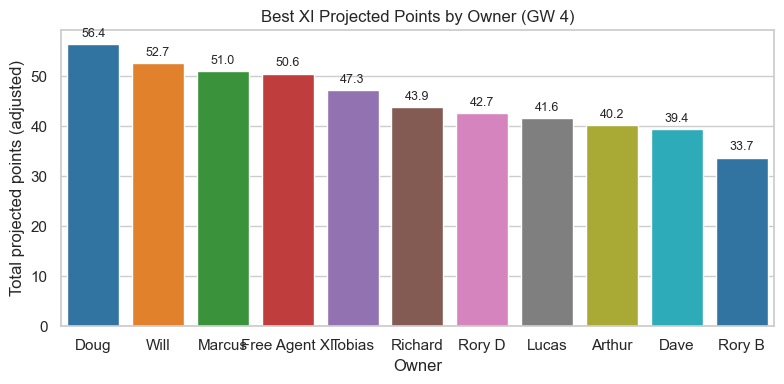

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_owner_summary = owner_summary.copy()

sns.barplot(
    data=plot_owner_summary,
    x='owner_name',
    y='predicted_points_adj_sum',
    hue='owner_name',
    legend=False,
    ax=ax,
    palette='tab10',
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

ax.set_title(f'Best XI Projected Points by Owner (GW {latest_gw})')
ax.set_xlabel('Owner')
ax.set_ylabel('Total projected points (adjusted)')
plt.xticks(rotation=0)
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'owner_best_xi_gw{latest_gw}.png', dpi=200)

## Season Trajectory: Cumulative Points by Owner

In [14]:
from league_points import get_current_gw, load_owner_actual_points, load_standings, compute_expected_league_points

current_gw = get_current_gw()
actual_points_df = load_owner_actual_points()

print(f'Real current GW: {current_gw}')
display(actual_points_df.sort_values(['owner_name', 'gw']).head(10))

Real current GW: 4


,gw,owner_name,actual_points,actual_league_points,finished
2,1,Arthur,51,3,True
17,2,Arthur,40,0,True
20,3,Arthur,38,3,True
39,4,Arthur,25,0,False
8,1,Dave,35,0,True
11,2,Dave,23,0,True
26,3,Dave,34,0,True
33,4,Dave,44,3,False
7,1,Doug,44,3,True
14,2,Doug,34,0,True


In [15]:
END_GW = 38  # season length (league stop_event)

def load_owner_projected_points(current_gw, end_gw=END_GW, predictions_dir=Path('..') / 'predictions'):
    """Best-XI (adjusted) projected total per owner for each future GW -- repeats
    the single-GW 'Best XI by Owner' logic above (get_best_11 on each owner's pool)
    once per remaining GW, reading that GW's own prediction file each time."""
    owner_dict = get_owner_dict()
    owner_name_map = {str(int(k)): v for k, v in owner_dict.items()}

    rows = []
    for gw in range(current_gw + 1, end_gw + 1):
        path = predictions_dir / f'predicted_gw{gw}_simple.csv'
        if not path.exists():
            continue
        gw_df = pd.read_csv(path)
        if 'predicted_points_adj' not in gw_df.columns:
            gw_df['predicted_points_adj'] = gw_df['predicted_points']
        gw_df['owner_name'] = gw_df['owner'].fillna(-1).astype(int).astype(str).map(owner_name_map).fillna('Free Agent')

        for owner_name in owner_dict.values():
            owner_pool = gw_df.query('owner_name == @owner_name')
            if owner_pool.empty:
                continue
            _, owner_best_11 = get_best_11(owner_pool)
            rows.append({
                'gw': gw,
                'owner_name': owner_name,
                'projected_points': owner_best_11['predicted_points_adj'].sum(),
            })
    return pd.DataFrame(rows)

projected_points_df = load_owner_projected_points(current_gw)
projected_points_df.sort_values(['owner_name', 'gw']).head(10)

,gw,owner_name,projected_points
7,5,Arthur,42.248492
17,6,Arthur,36.602550
27,7,Arthur,44.279924
37,8,Arthur,37.987351
47,9,Arthur,42.808831
57,10,Arthur,39.452316
67,11,Arthur,42.978494
77,12,Arthur,40.465208
87,13,Arthur,40.097827
97,14,Arthur,52.836758


In [16]:
owner_names = list(get_owner_dict().values())
trajectory_rows = []

for owner_name in owner_names:
    # Real: cumulative actual points through the current (possibly live) GW -- solid.
    owner_actual = actual_points_df.query('owner_name == @owner_name').sort_values('gw')
    cumulative = 0.0
    for _, row in owner_actual.iterrows():
        cumulative += row['actual_points']
        trajectory_rows.append({'owner_name': owner_name, 'gw': row['gw'], 'cumulative_points': cumulative, 'kind': 'actual'})

    # Anchor the projected segment at the same point so the dotted line starts
    # exactly where the solid line ends (no visual gap at current_gw).
    trajectory_rows.append({'owner_name': owner_name, 'gw': current_gw, 'cumulative_points': cumulative, 'kind': 'projected'})

    # Projected: keep adding each future GW's best-XI total -- dotted.
    owner_projected = projected_points_df.query('owner_name == @owner_name').sort_values('gw')
    for _, row in owner_projected.iterrows():
        cumulative += row['projected_points']
        trajectory_rows.append({'owner_name': owner_name, 'gw': row['gw'], 'cumulative_points': cumulative, 'kind': 'projected'})

trajectory_df = pd.DataFrame(trajectory_rows)
trajectory_df.head()

,owner_name,gw,cumulative_points,kind
0,Lucas,1,29.0,actual
1,Lucas,2,84.0,actual
2,Lucas,3,110.0,actual
3,Lucas,4,152.0,actual
4,Lucas,4,152.0,projected


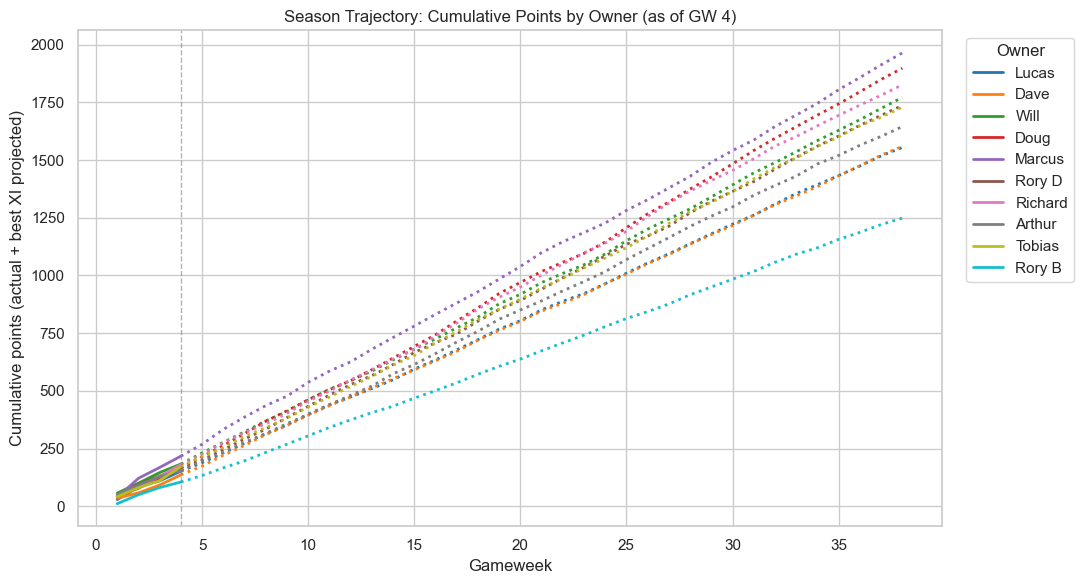

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette('tab10', n_colors=len(owner_names))
color_by_owner = dict(zip(owner_names, palette))

for owner_name in owner_names:
    owner_traj = trajectory_df.query('owner_name == @owner_name').sort_values('gw')
    color = color_by_owner[owner_name]
    actual_seg = owner_traj.query('kind == "actual"')
    projected_seg = owner_traj.query('kind == "projected"')
    ax.plot(actual_seg['gw'], actual_seg['cumulative_points'], color=color, linestyle='-', linewidth=2, label=owner_name)
    ax.plot(projected_seg['gw'], projected_seg['cumulative_points'], color=color, linestyle=':', linewidth=2)

ax.axvline(current_gw, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title(f'Season Trajectory: Cumulative Points by Owner (as of GW {current_gw})')
ax.set_xlabel('Gameweek')
ax.set_ylabel('Cumulative points (actual + best XI projected)')
ax.legend(title='Owner', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'season_trajectory_gw{current_gw}.png', dpi=200)

## Expected League Points: Actual vs Expected (Luck)

Each GW, rank every owner by their actual score that week (1st to last) and award a
linear share of 3 points down to 0 -- `3 * (n_owners - rank) / (n_owners - 1)` -- as if
that week were a mini round-robin against the whole league, not just your one assigned
H2H opponent. Comparing the cumulative version of this against your real cumulative H2H
league points shows whether you've been over- or under-performing your weekly form due
to a favorable/unfavorable schedule.

In [18]:
expected_points_df = compute_expected_league_points(actual_points_df)

league_points_df = expected_points_df.sort_values(['owner_name', 'gw']).copy()
league_points_df['cumulative_actual_league_points'] = league_points_df.groupby('owner_name')['actual_league_points'].cumsum()
league_points_df['cumulative_expected_league_points'] = league_points_df.groupby('owner_name')['expected_league_points'].cumsum()

display(league_points_df.head(10))

# Sanity check: derived actual_league_points (3/1/0 from comparing raw match points)
# should sum to the same cumulative total the API itself reports in standings -- but
# only through the last *finished* GW, since the live standings total doesn't yet
# include a GW that's merely started (in progress).
finished_cumulative = (
    league_points_df.query('finished')
    .groupby('owner_name')
    .tail(1)[['owner_name', 'gw', 'cumulative_actual_league_points']]
)
standings_df = load_standings()
check_df = finished_cumulative.merge(standings_df[['owner_name', 'total', 'rank']], on='owner_name').sort_values('rank')
check_df['matches_standings'] = check_df['cumulative_actual_league_points'] == check_df['total']

if not check_df['matches_standings'].all():
    print('WARNING: derived actual_league_points does not match live standings total for:')
    display(check_df.query('~matches_standings'))
else:
    print('Sanity check passed (through the last finished GW): derived actual_league_points matches live standings total for all owners.')
display(check_df)

,gw,owner_name,actual_points,actual_league_points,finished,rank,expected_league_points,cumulative_actual_league_points,cumulative_expected_league_points
2,1,Arthur,51,3,True,2.0,2.666667,3,2.666667
17,2,Arthur,40,0,True,5.0,1.666667,3,4.333333
20,3,Arthur,38,3,True,5.0,1.666667,6,6.000000
39,4,Arthur,25,0,False,9.0,0.333333,6,6.333333
8,1,Dave,35,0,True,8.0,0.666667,0,0.666667
11,2,Dave,23,0,True,10.0,0.000000,0,0.666667
26,3,Dave,34,0,True,7.0,1.000000,0,1.666667
33,4,Dave,44,3,False,4.0,2.000000,3,3.666667
7,1,Doug,44,3,True,4.0,2.000000,3,2.000000
14,2,Doug,34,0,True,9.0,0.333333,3,2.333333


Sanity check passed (through the last finished GW): derived actual_league_points matches live standings total for all owners.


,owner_name,gw,cumulative_actual_league_points,total,rank,matches_standings
9,Will,3,7,7,1,True
4,Marcus,3,6,6,2,True
7,Rory D,3,6,6,3,True
5,Richard,3,6,6,4,True
0,Arthur,3,6,6,5,True
8,Tobias,3,6,6,6,True
2,Doug,3,4,4,7,True
3,Lucas,3,3,3,8,True
1,Dave,3,0,0,9,True
6,Rory B,3,0,0,10,True


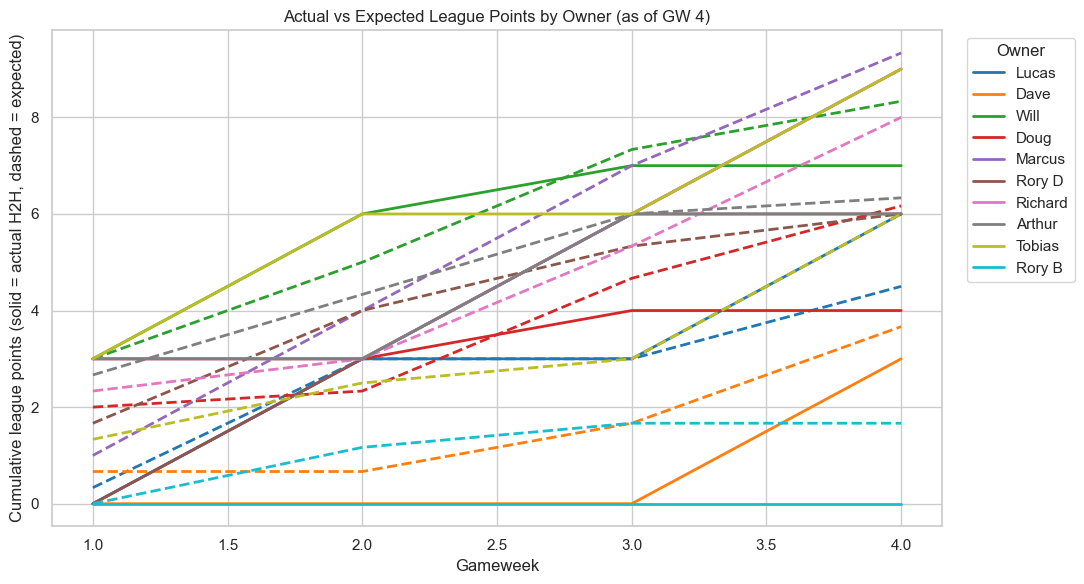

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))

for owner_name in owner_names:
    owner_lp = league_points_df.query('owner_name == @owner_name').sort_values('gw')
    color = color_by_owner[owner_name]
    ax.plot(owner_lp['gw'], owner_lp['cumulative_actual_league_points'], color=color, linestyle='-', linewidth=2, label=owner_name)
    ax.plot(owner_lp['gw'], owner_lp['cumulative_expected_league_points'], color=color, linestyle='--', linewidth=2)

ax.set_title(f'Actual vs Expected League Points by Owner (as of GW {current_gw})')
ax.set_xlabel('Gameweek')
ax.set_ylabel('Cumulative league points (solid = actual H2H, dashed = expected)')
ax.legend(title='Owner', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'expected_league_points_gw{current_gw}.png', dpi=200)

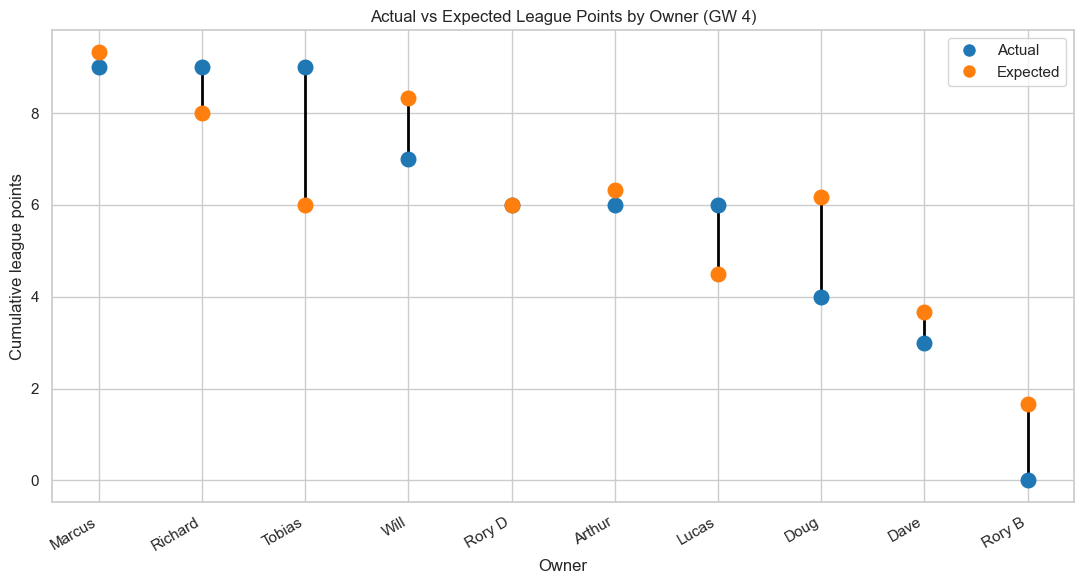

In [20]:
from matplotlib.lines import Line2D

# One row per owner: their cumulative actual/expected league points as of the most
# recent GW (current_gw, which may still be live/in-progress -- same convention as
# the trajectory chart above). Ranked by actual league points, matching the real table.
latest_lp = (
    league_points_df.groupby('owner_name').tail(1)
    .sort_values('cumulative_actual_league_points', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(latest_lp))

for i, row in latest_lp.iterrows():
    ax.plot([i, i], [row['cumulative_expected_league_points'], row['cumulative_actual_league_points']],
            color='black', linewidth=2, zorder=1)

ax.scatter(x, latest_lp['cumulative_actual_league_points'], color='tab:blue', s=110, zorder=2)
ax.scatter(x, latest_lp['cumulative_expected_league_points'], color='tab:orange', s=110, zorder=2)

ax.set_xticks(list(x))
ax.set_xticklabels(latest_lp['owner_name'], rotation=30, ha='right')
ax.set_title(f'Actual vs Expected League Points by Owner (GW {current_gw})')
ax.set_xlabel('Owner')
ax.set_ylabel('Cumulative league points')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=10, label='Actual'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=10, label='Expected'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'lollipop_expected_league_points_gw{current_gw}.png', dpi=200)

## Shareable Plots

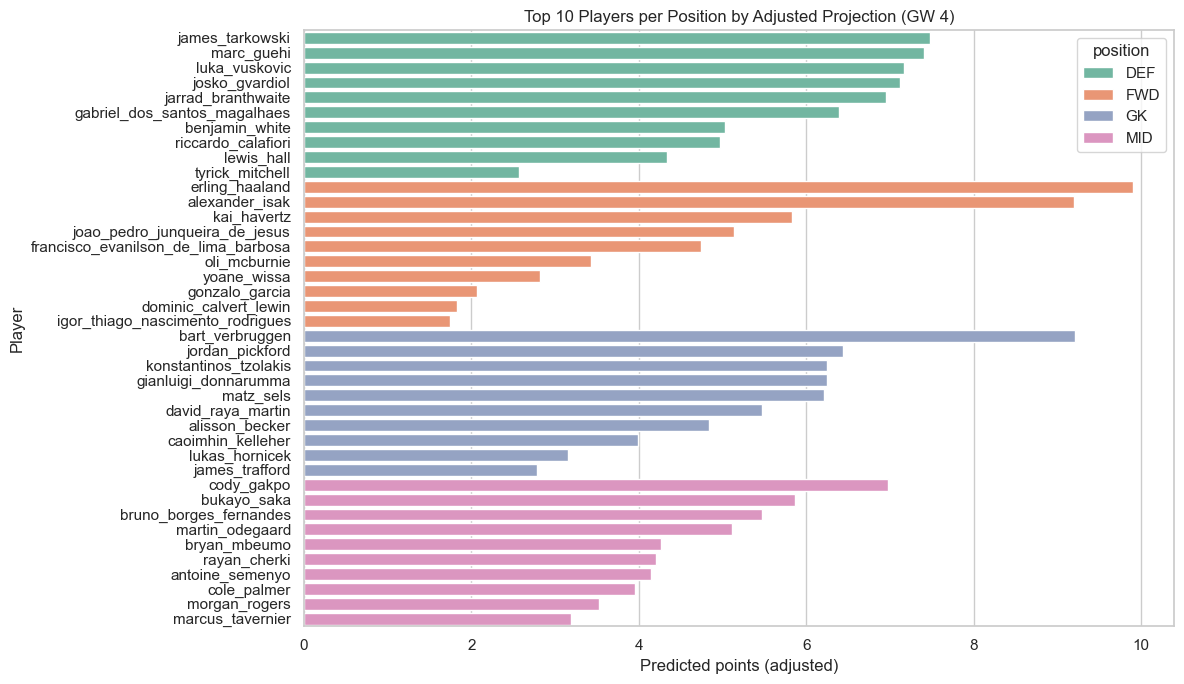

In [21]:
plot_df = (
    df_sorted
    .groupby('position', group_keys=False)
    .head(10)
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_df.sort_values(['position', 'predicted_points_adj'], ascending=[True, False]),
    x='predicted_points_adj',
    y='full_name',
    hue='position',
    dodge=False,
    ax=ax,
    palette='Set2',
)
ax.set_title(f'Top 10 Players per Position by Adjusted Projection (GW {latest_gw})')
ax.set_xlabel('Predicted points (adjusted)')
ax.set_ylabel('Player')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'top10_by_position_gw{latest_gw}.png', dpi=200)

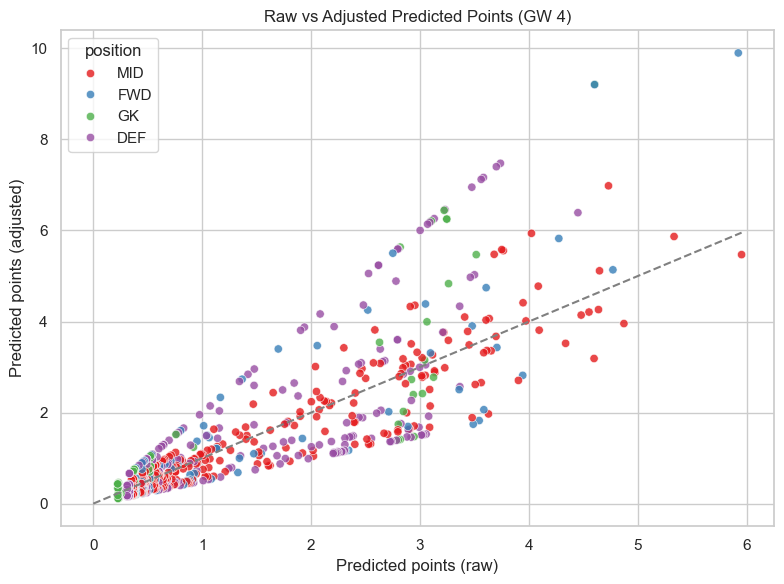

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_sorted,
    x='predicted_points',
    y='predicted_points_adj',
    hue='position',
    alpha=0.8,
    ax=ax,
    palette='Set1',
)
ax.plot([0, df_sorted['predicted_points'].max()], [0, df_sorted['predicted_points'].max()], linestyle='--', color='grey')
ax.set_title(f'Raw vs Adjusted Predicted Points (GW {latest_gw})')
ax.set_xlabel('Predicted points (raw)')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'raw_vs_adjusted_gw{latest_gw}.png', dpi=200)

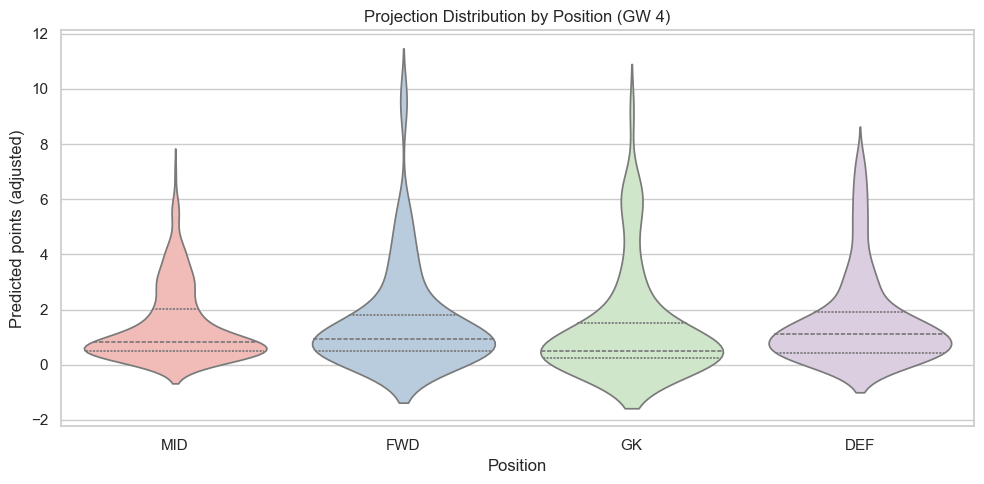

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_sorted,
    x='position',
    y='predicted_points_adj',
    inner='quartile',
    hue='position',
    legend=False,
    ax=ax,
    palette='Pastel1',
)
ax.set_title(f'Projection Distribution by Position (GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'distribution_by_position_gw{latest_gw}.png', dpi=200)

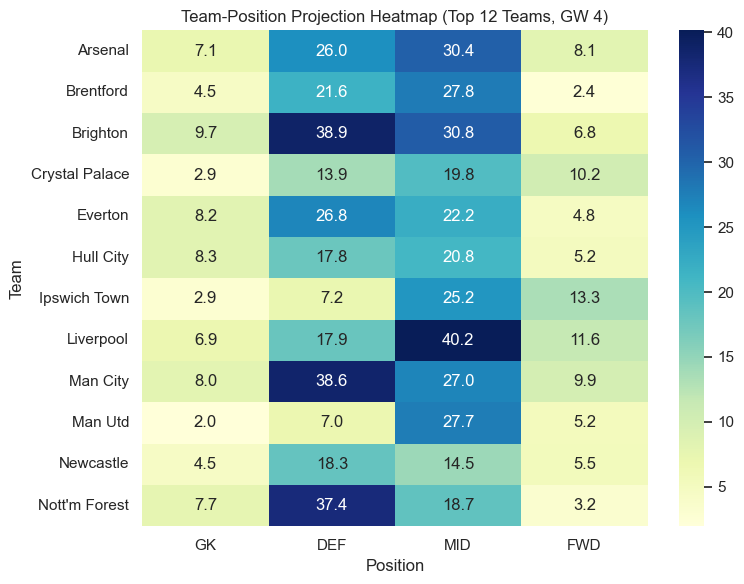

In [24]:
team_pos = (
    df_sorted
    .groupby(['team', 'position'], as_index=False)['predicted_points_adj']
    .sum()
)

team_total = team_pos.groupby('team', as_index=False)['predicted_points_adj'].sum()
top_teams = team_total.sort_values('predicted_points_adj', ascending=False).head(12)['team']
heat_df = team_pos[team_pos['team'].isin(top_teams)].pivot(index='team', columns='position', values='predicted_points_adj').fillna(0)
heat_df = heat_df[['GK', 'DEF', 'MID', 'FWD']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title(f'Team-Position Projection Heatmap (Top 12 Teams, GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Team')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'team_position_heatmap_gw{latest_gw}.png', dpi=200)

In [25]:
share_cols = ['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj',
              'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
share_table = df_sorted[share_cols].head(25).copy()
share_table

,full_name,position,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bruno_borges_fernandes,MID,Man Utd,Lucas,5.952156,5.469668,7.322797,7.035839,0.918939
1,erling_haaland,FWD,Man City,Rory D,5.921801,9.899650,9.506332,9.799536,1.671729
2,bukayo_saka,MID,Arsenal,Arthur,5.332282,5.867893,5.470413,6.251598,1.100447
3,cole_palmer,MID,Chelsea,Richard,4.872068,3.955313,4.694859,5.379146,0.811835
4,joao_pedro_junqueira_de_jesus,FWD,Chelsea,Tobias,4.770818,5.136184,6.121004,7.249860,1.076584
5,cody_gakpo,MID,Liverpool,Rory D,4.730270,6.981515,5.488713,4.647267,1.475923
6,martin_odegaard,MID,Arsenal,Doug,4.647928,5.114798,4.768331,5.449258,1.100447
7,bryan_mbeumo,MID,Man Utd,Rory B,4.638302,4.262317,5.706393,5.482778,0.918939
8,bart_verbruggen,GK,Brighton,Tobias,4.604440,9.208879,5.729969,4.604440,2.000000
9,alexander_isak,FWD,Liverpool,Marcus,4.602130,9.204259,7.237140,7.604582,2.000000


In [26]:
if EXPORT_FIGURES:
    print(f'Saved figures to: {FIG_DIR.resolve()}')
else:
    print('Set EXPORT_FIGURES = True to save PNG charts for sharing.')

Set EXPORT_FIGURES = True to save PNG charts for sharing.


## Historical Backtest: Predicted vs Actual (All GWs)

In [27]:
import re
import sys
import requests

sys.path.append(str(Path('../..').resolve()))
from wrangle_data_funcs import clean_name

predictions_dir = Path('..') / 'predictions'
pred_files = sorted(predictions_dir.glob('predicted_gw[0-9]*.csv'))

gw_file_pairs = []
for file_path in pred_files:
    if file_path.name.endswith('_simple.csv'):
        continue
    match = re.search(r'predicted_gw(\d+)\.csv$', file_path.name)
    if match:
        gw_file_pairs.append((int(match.group(1)), file_path))

gw_file_pairs = sorted(gw_file_pairs, key=lambda x: x[0])
print(f'Found GW prediction files: {len(gw_file_pairs)}')

bootstrap = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/', timeout=20).json()
name_by_element = {}
for elem in bootstrap['elements']:
    full_name = clean_name(f"{elem['first_name']}_{elem['second_name']}")
    name_by_element[elem['id']] = full_name

def load_actual_points_for_gw_from_api(gw):
    event_live = requests.get(f'https://fantasy.premierleague.com/api/event/{gw}/live/', timeout=20).json()
    rows = []
    for item in event_live.get('elements', []):
        element_id = item.get('id')
        full_name = name_by_element.get(element_id)
        if full_name is None:
            continue
        total_points = item.get('stats', {}).get('total_points', np.nan)
        rows.append({'full_name': full_name, 'actual_points': total_points})

    actual_gw_df = pd.DataFrame(rows)
    if actual_gw_df.empty:
        raise ValueError(f'No actual rows returned from FPL API for GW {gw}')

    return actual_gw_df

backtest_frames = []
skipped_gws = []
for gw, file_path in gw_file_pairs:
    pred_gw_df = pd.read_csv(file_path)
    if 'predicted_points_adj' not in pred_gw_df.columns:
        pred_gw_df['predicted_points_adj'] = pred_gw_df['predicted_points']

    try:
        actual_gw_df = load_actual_points_for_gw_from_api(gw)
    except Exception as exc:
        skipped_gws.append((gw, str(exc)))
        continue

    merged = pred_gw_df.merge(actual_gw_df, on='full_name', how='inner')
    if merged.empty:
        skipped_gws.append((gw, 'No name overlap between prediction and actual files'))
        continue

    merged['gw'] = gw
    backtest_frames.append(
        merged[['gw', 'full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'actual_points']]
    )

backtest_df = pd.concat(backtest_frames, ignore_index=True) if backtest_frames else pd.DataFrame()
print(f'Total merged player-GW rows: {len(backtest_df):,}')
if skipped_gws:
    print(f'Skipped GWs: {[gw for gw, _ in skipped_gws]}')

if not backtest_df.empty:
    backtest_df['error_raw'] = backtest_df['predicted_points'] - backtest_df['actual_points']
    backtest_df['error_adj'] = backtest_df['predicted_points_adj'] - backtest_df['actual_points']
    backtest_df['abs_error_raw'] = backtest_df['error_raw'].abs()
    backtest_df['abs_error_adj'] = backtest_df['error_adj'].abs()

backtest_df.head()

Found GW prediction files: 37


Total merged player-GW rows: 1,887
Skipped GWs: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]


,gw,full_name,position,team,predicted_points,predicted_points_adj,actual_points,error_raw,error_adj,abs_error_raw,abs_error_adj
0,2,aaron_anselmino,DEF,Chelsea,0.782188,0.391094,0,0.782188,0.391094,0.782188,0.391094
1,2,aaron_hickey,DEF,Brentford,1.512935,3.025870,1,0.512935,2.025870,0.512935,2.025870
2,2,abdoul_ouattara,DEF,Ipswich Town,0.947001,1.894002,1,-0.052999,0.894002,0.052999,0.894002
3,2,abdukodir_khusanov,DEF,Man City,3.211374,6.422748,2,1.211374,4.422748,1.211374,4.422748
4,2,abdul_fatawu,MID,Ipswich Town,2.414172,1.984991,4,-1.585828,-2.015009,1.585828,2.015009


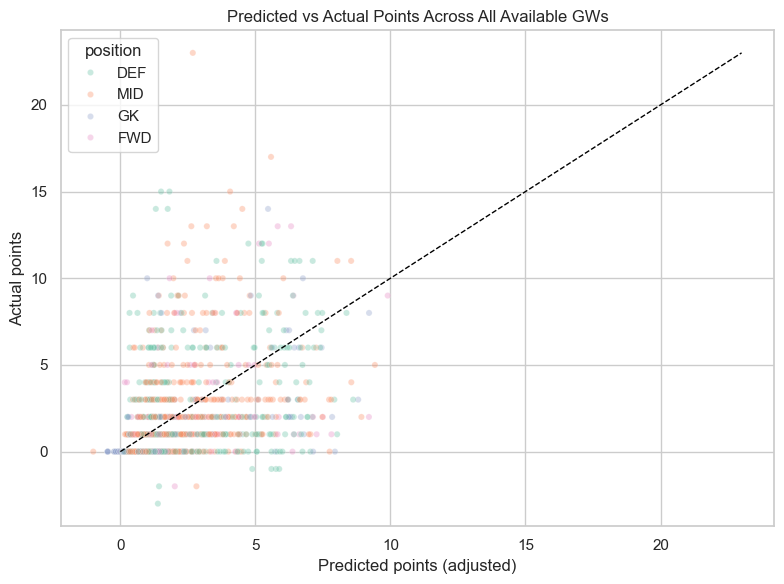

In [28]:
if backtest_df.empty:
    print('No backtest rows available. Check BACKTEST_YEAR and prediction files.')
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=backtest_df,
        x='predicted_points_adj',
        y='actual_points',
        hue='position',
        alpha=0.35,
        s=20,
        ax=ax,
        palette='Set2',
    )

    max_axis = max(backtest_df['predicted_points_adj'].max(), backtest_df['actual_points'].max(), 1)
    ax.plot([0, max_axis], [0, max_axis], linestyle='--', color='black', linewidth=1)
    ax.set_title(f'Predicted vs Actual Points Across All Available GWs')
    ax.set_xlabel('Predicted points (adjusted)')
    ax.set_ylabel('Actual points')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'pred_vs_actual_all_gws.png', dpi=200)

,gw,mae_raw,mae_adj,rmse_raw,rmse_adj,corr_adj,n_players
0,2,1.269875,1.471447,2.139009,2.495223,0.453176,609
1,3,1.241781,1.405630,1.987240,2.208180,0.492621,625
2,4,1.319584,1.302080,2.193797,2.166706,0.581621,653


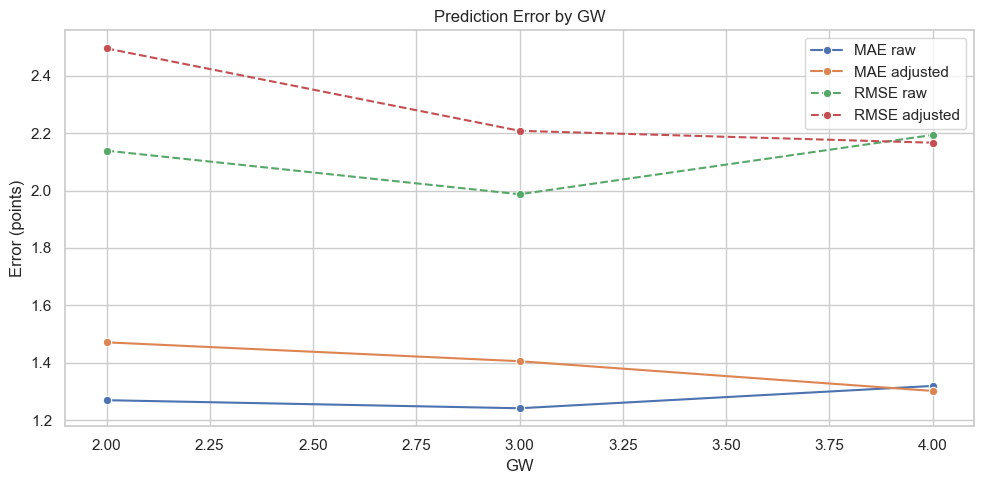

In [29]:
if backtest_df.empty:
    print('No backtest rows available. Skipping GW metric plots.')
else:
    gw_metrics = (
        backtest_df.groupby('gw', as_index=False)
        .agg(
            mae_raw=('abs_error_raw', 'mean'),
            mae_adj=('abs_error_adj', 'mean'),
            rmse_raw=('error_raw', lambda x: np.sqrt(np.mean(np.square(x)))),
            rmse_adj=('error_adj', lambda x: np.sqrt(np.mean(np.square(x)))),
            corr_adj=('predicted_points_adj', lambda x: x.corr(backtest_df.loc[x.index, 'actual_points'])),
            n_players=('full_name', 'count'),
        )
    )

    display(gw_metrics)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=gw_metrics, x='gw', y='mae_raw', marker='o', label='MAE raw', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='mae_adj', marker='o', label='MAE adjusted', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_raw', marker='o', label='RMSE raw', ax=ax, linestyle='--')
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_adj', marker='o', label='RMSE adjusted', ax=ax, linestyle='--')
    ax.set_title('Prediction Error by GW')
    ax.set_xlabel('GW')
    ax.set_ylabel('Error (points)')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'prediction_error_by_gw.png', dpi=200)

### What Is corr_adj?

`corr_adj` is the Pearson correlation between `predicted_points_adj` and `actual_points` within each GW.

- `corr_adj` near `1.0`: your model ranked players very well that week.
- `corr_adj` near `0.0`: weak relationship between predictions and outcomes.
- `corr_adj` below `0.0`: rankings were directionally wrong that week.

This is most useful for judging ranking quality, not absolute error size.

,gw,corr_adj
0,2,0.453176
1,3,0.492621
2,4,0.581621


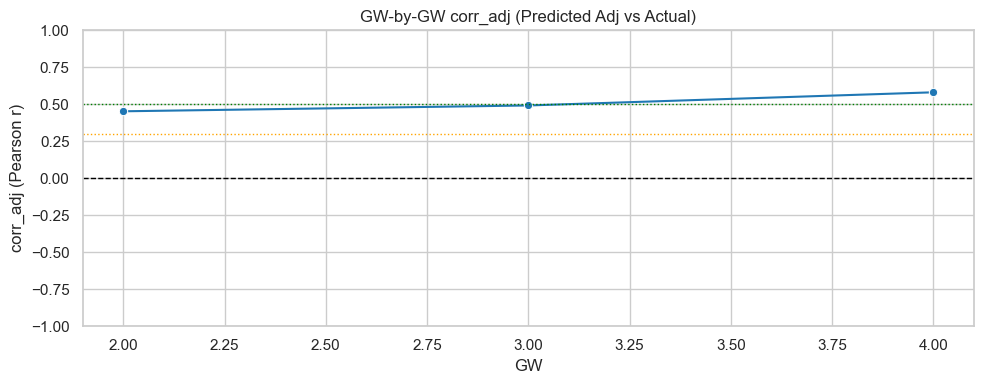

In [30]:
if backtest_df.empty:
    print('No backtest rows available. Skipping corr_adj plot.')
else:
    corr_plot_df = gw_metrics[['gw', 'corr_adj']].dropna().copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=corr_plot_df, x='gw', y='corr_adj', marker='o', ax=ax, color='#1f77b4')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0.5, color='green', linestyle=':', linewidth=1)
    ax.axhline(0.3, color='orange', linestyle=':', linewidth=1)
    ax.set_ylim(-1, 1)
    ax.set_title('GW-by-GW corr_adj (Predicted Adj vs Actual)')
    ax.set_xlabel('GW')
    ax.set_ylabel('corr_adj (Pearson r)')
    plt.tight_layout()

    display(corr_plot_df)

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'corr_adj_by_gw.png', dpi=200)